In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch 
from torch import nn
from difflogic import LogicLayer, GroupSum
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot
import sys
from hydra import compose, initialize
from omegaconf import OmegaConf, DictConfig
import torch
import os
import random
import mnist_dataset
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset
import torchvision.transforms as transforms
from tqdm import tqdm

In [20]:
# 3 models we plan on using
# model_076 | 400x5000 -> 5000x10 
# model_077 | 400x1250 -> 1250x1250 -> 1250x1250 -> 1250x10 
# model_078 | 400x2500 -> 2500x2500 -> 2500x10 

In [18]:
import DiffLogicMnist as difflog
from DiffLogicMnist import os, initialize, compose, Model, test_loader, train_loader, LogicLayer
import torch
import numpy as np
from tqdm import tqdm
import pickle

In [4]:
model_name = 'model_077'
model_name_config = model_name # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = 'trained_models'
PATH = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH)
# print(model)

model.get_accuracy(test_loader)

LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)


Running Inference: 100%|██████████| 34/34 [00:08<00:00,  4.14it/s]


0.9137178308823529

### Switching Probabilities

##### Currently unused, but this function is a simpler version of the one below

In [6]:
def get_node_activation_counts(model, data_loader):
    """
    Tracks how often each neuron in each LogicLayer fires (activates to 1),
    handling different layer sizes separately.

    Args:
        model: The trained DiffLogic model.
        data_loader: DataLoader with the dataset to evaluate (e.g., test_loader).

    Returns:
        switching_probs_per_layer: A list of arrays, each containing the switching probabilities for a layer.
    """

    # To track activations for each layer separately
    activation_counts_per_layer = []
    hooks = []

    # Hook function to count activations for each layer
    def hook_fn(module, input, output, layer_idx):
        # Initialize activation counts for the layer if not done already
        if len(activation_counts_per_layer) <= layer_idx:
            activation_counts_per_layer.append(np.zeros(output.size(1)))
        
        # Count how many times each neuron fired (output > 0 means it fired)
        activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

    # Register hooks on all LogicLayers and track the layer index
    for idx, layer in enumerate(model.diff_logic_model.logic_layers):
        if isinstance(layer, LogicLayer):
            hook = layer.register_forward_hook(lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx))
            hooks.append(hook)

    model.diff_logic_model.eval()  # Set model to evaluation mode
    total_images = 0  # Track total number of images processed

    with torch.no_grad():  # Disable gradient computation
        for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
            batch_inputs = batch_inputs.to('cuda')
            model.diff_logic_model(batch_inputs)  # Forward pass
            total_images += batch_inputs.size(0)

    # Calculate switching probabilities for each layer
    switching_probs_per_layer = [activation_counts / total_images for activation_counts in activation_counts_per_layer]

    # Remove hooks to clean up
    for hook in hooks:
        hook.remove()

    return switching_probs_per_layer

# Use the model
switching_probs = get_node_activation_counts(model, test_loader)

# Print or save the switching probabilities per layer
for idx, probs in enumerate(switching_probs):
    print(f"Layer {idx + 1} Switching Probabilities: {probs}")

Processing MNIST images: 100%|██████████| 34/34 [00:02<00:00, 15.39it/s]

Layer 1 Switching Probabilities: [0.21748621 0.08352482 0.68164062 ... 0.36408548 0.97805607 0.56479779]
Layer 2 Switching Probabilities: [0.67325368 0.38488051 0.99299173 ... 0.37270221 0.98747702 0.97460938]


In [10]:
switching_probs

def count_numbers(arrays):
    # Flatten the list of arrays into one array
    all_numbers = arrays

    # Count how many numbers are greater than 0.5
    greater_than_05 = np.sum(all_numbers > 0.5)

    # Count how many numbers are less than or equal to 0.5
    less_than_or_equal_to_05 = np.sum(all_numbers <= 0.5)

    return greater_than_05, less_than_or_equal_to_05

greater, less_or_equal = count_numbers(switching_probs[0])
greater, less_or_equal

(1876, 624)

##### Returns a dictionary with switching probabilities, learned gate type and inputs

In [11]:
# ALL_OPERATIONS is used to map the argmax value of the weights to the corresponding logic gate
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"
]

In [31]:
def get_gate_switching_probs(model, data_loader):
    """
    Tracks the learned logic gate (based on weights) and the switching probability for each neuron.

    Args:
        model: The trained DiffLogic model.
        data_loader: DataLoader with the dataset to evaluate (e.g., test_loader).

    Returns:
        gate_prob_dict_per_layer: A list of dictionaries, each containing the learned gate and switching probability for neurons in a layer.
    """
    activation_counts_per_layer = []
    gates_per_layer = []
    gates_initialized = []  # Track whether gates have been initialized for each layer
    hooks = []

    # Hook function to track activations and logic gates for each neuron
    def hook_fn(module, input, output, layer_idx):
        # Initialize activation counts and gates for the layer if not done already
        if len(activation_counts_per_layer) <= layer_idx:
            activation_counts_per_layer.append(np.zeros(output.size(1)))
            gates_per_layer.append([])
            gates_initialized.append(False)  # Mark that gates are not initialized yet for this layer

        # Store activations (output > 0 means it fired)
        activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

        # Only store learned logic gates if they haven't been recorded yet
        if not gates_initialized[layer_idx]:
            for neuron_idx in range(output.size(1)):
                # Get the learned gate by taking the argmax of the weights for the neuron
                gate_op_idx = module.weights[neuron_idx].argmax().item()
                learned_gate = ALL_OPERATIONS[gate_op_idx]

                # Get the input connections (indices) for the gate
                input_neuron_a = module.indices[0][neuron_idx].item()
                input_neuron_b = module.indices[1][neuron_idx].item()

                gates_per_layer[layer_idx].append({
                    'Gate': learned_gate,
                    'Inputs': (input_neuron_a, input_neuron_b)
                })

            # Mark that gates have been initialized for this layer
            gates_initialized[layer_idx] = True

    # Register hooks on all LogicLayers and track the layer index
    for idx, layer in enumerate(model.diff_logic_model.logic_layers):
        if isinstance(layer, LogicLayer):
            hook = layer.register_forward_hook(lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx))
            hooks.append(hook)

    model.diff_logic_model.eval()  # Set model to evaluation mode
    total_images = 0  # Track total number of images processed

    with torch.no_grad():  # Disable gradient computation
        for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
            batch_inputs = batch_inputs.to('cuda')
            model.diff_logic_model(batch_inputs)  # Forward pass
            total_images += batch_inputs.size(0)

    # Calculate switching probabilities and create dictionaries of gate + switching prob for each layer
    gate_prob_dict_per_layer = []
    for layer_idx in range(len(activation_counts_per_layer)):
        layer_probs = activation_counts_per_layer[layer_idx] / total_images

        # Debugging: Check if lengths match before proceeding
        num_gates = len(gates_per_layer[layer_idx])
        num_activations = len(layer_probs)

        print(f"Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")

        if num_gates != num_activations:
            print(f"Warning: Mismatch in Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")
            continue  # Skip this layer if there is a mismatch

        gate_prob_dict = {
            f"Gate {i+1}": {
                "Learned Gate": gates_per_layer[layer_idx][i]['Gate'], 
                "Inputs": gates_per_layer[layer_idx][i]['Inputs'],
                "Switching Probability": layer_probs[i]
            }
            for i in range(num_gates)  # Loop only through available gates
        }
        
        gate_prob_dict_per_layer.append(gate_prob_dict)

    # Remove hooks to clean up
    for hook in hooks:
        hook.remove()

    return gate_prob_dict_per_layer

# Use the model = get_gate_switching_probs(model, test_loader)
gate_switching_probs = get_gate_switching_probs(model, test_loader)

Processing MNIST images: 100%|██████████| 34/34 [00:02<00:00, 16.88it/s]

Layer 1 - Gates: 2500, Activations: 2500
Layer 2 - Gates: 2500, Activations: 2500


In [16]:
# saving the gate_switching_probs to a file
def save_gate_switching_probs(gate_switching_probs, file_path):
    with open(file_path, 'wb') as file:
        pickle.dump(gate_switching_probs, file)
    print(f"Gate switching probabilities saved to {file_path}")

file_path = f"gate_switching_probs/{model_name}_gate_switching_probs.pkl"
save_gate_switching_probs(gate_switching_probs, file_path)

Gate switching probabilities saved to gate_switching_probs/model_077_gate_switching_probs.pkl


In [17]:
# loading the gate_switching_probs from a file
def load_gate_switching_probs(file_path):
    with open(file_path, 'rb') as file:
        gate_switching_probs = pickle.load(file)
    print(f"Gate switching probabilities loaded from {file_path}")
    return gate_switching_probs

# usage example
loaded_gate_switching_probs = load_gate_switching_probs(file_path)
loaded_gate_switching_probs

Gate switching probabilities loaded from gate_switching_probs/model_077_gate_switching_probs.pkl


[{'Gate 1': {'Learned Gate': 'or',
   'Inputs': (382, 383),
   'Switching Probability': 0.21748621323529413},
  'Gate 2': {'Learned Gate': 'b',
   'Inputs': (57, 240),
   'Switching Probability': 0.08352481617647059},
  'Gate 3': {'Learned Gate': 'xor',
   'Inputs': (352, 137),
   'Switching Probability': 0.681640625},
  'Gate 4': {'Learned Gate': 'not_implies',
   'Inputs': (310, 125),
   'Switching Probability': 0.5422794117647058},
  'Gate 5': {'Learned Gate': 'not_and',
   'Inputs': (49, 145),
   'Switching Probability': 0.9916130514705882},
  'Gate 6': {'Learned Gate': 'implies',
   'Inputs': (48, 274),
   'Switching Probability': 0.9888556985294118},
  'Gate 7': {'Learned Gate': 'a',
   'Inputs': (28, 86),
   'Switching Probability': 0.6453354779411765},
  'Gate 8': {'Learned Gate': 'not_a',
   'Inputs': (26, 311),
   'Switching Probability': 0.9852941176470589},
  'Gate 9': {'Learned Gate': 'not_b',
   'Inputs': (207, 341),
   'Switching Probability': 0.9958639705882353},
  'Gat

##### Visualize Switching Probabilities Across Layers

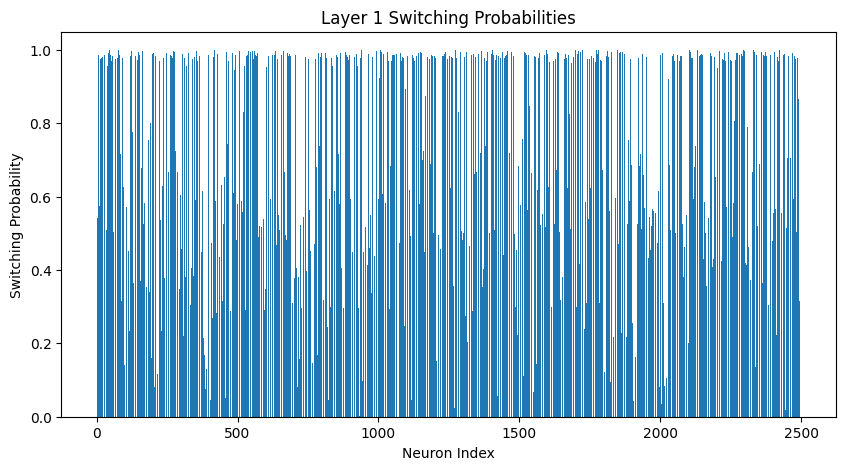

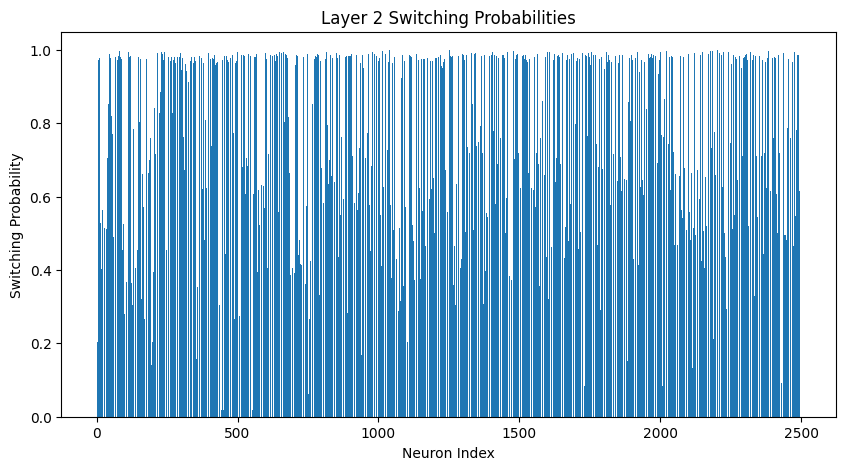

In [20]:
def visualize_switching_probabilities(switching_probs):
    """
    Plots switching probabilities across layers as a bar chart or heatmap.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(probs)), probs)
        plt.title(f"Layer {idx + 1} Switching Probabilities")
        plt.xlabel("Neuron Index")
        plt.ylabel("Switching Probability")
        plt.show()

visualize_switching_probabilities(switching_probs)

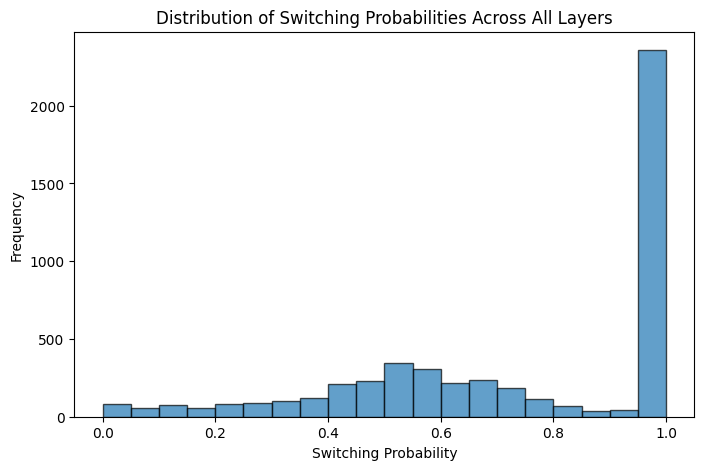

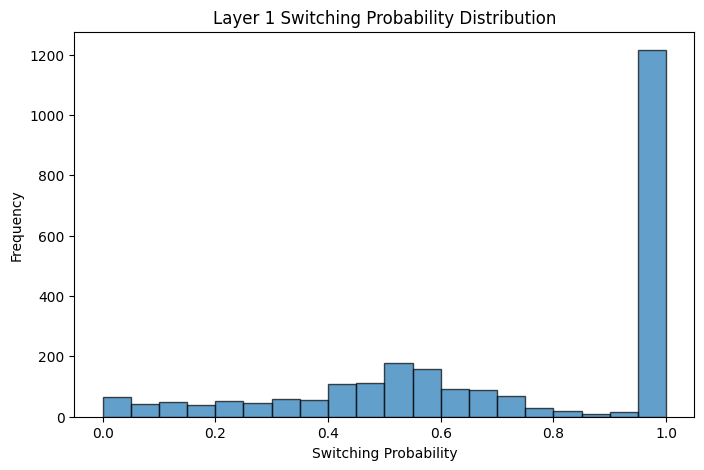

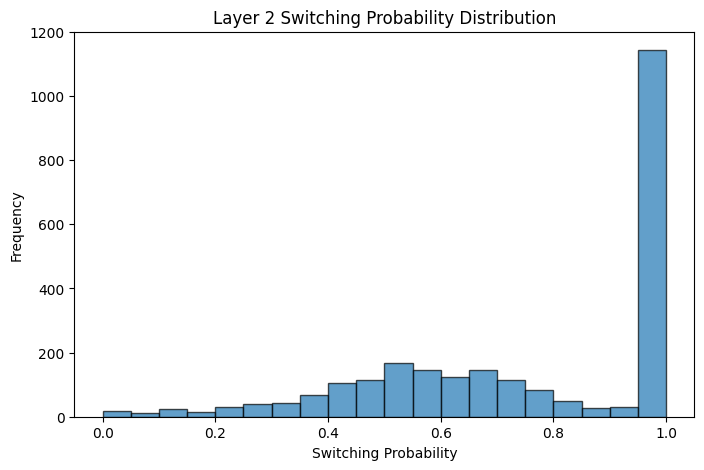

In [21]:
import matplotlib.pyplot as plt

def visualize_switching_probabilities(switching_probs):
    """
    Plots the distribution of switching probabilities across layers using histograms.
    
    Args:
        switching_probs: List of arrays, each containing the switching probabilities for a layer.
    """
    # Flatten all switching probabilities into a single list to plot the overall distribution
    all_probs = [prob for layer_probs in switching_probs for prob in layer_probs]

    # Plot the distribution of switching probabilities for all layers
    plt.figure(figsize=(8, 5))
    plt.hist(all_probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
    plt.title("Distribution of Switching Probabilities Across All Layers")
    plt.xlabel("Switching Probability")
    plt.ylabel("Frequency")
    plt.show()

    # Plot histograms for each layer
    for idx, probs in enumerate(switching_probs):
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Layer {idx + 1} Switching Probability Distribution")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

# Example usage
visualize_switching_probabilities(switching_probs)

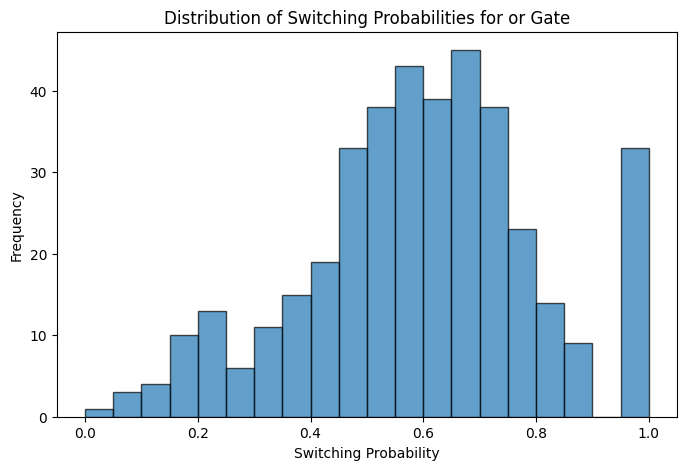

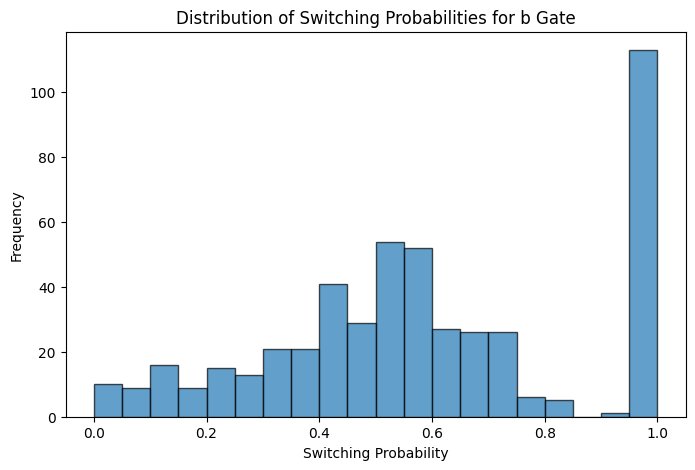

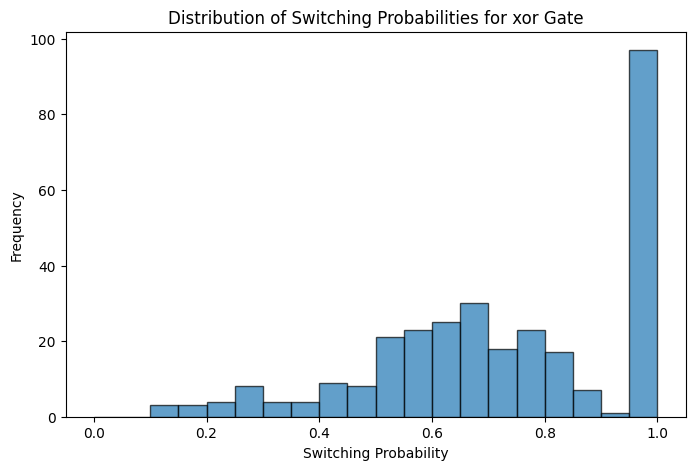

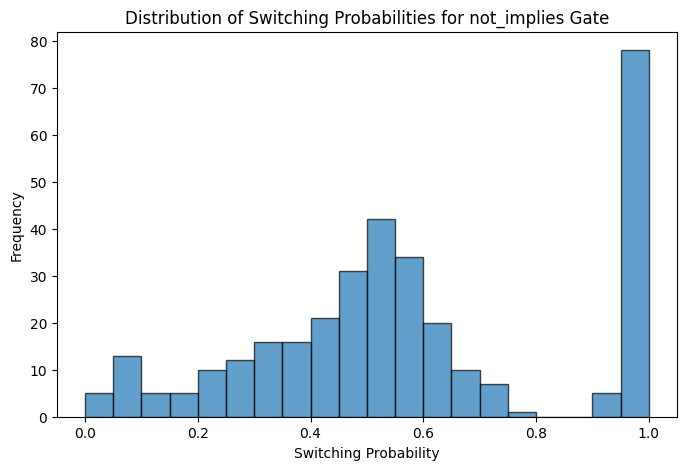

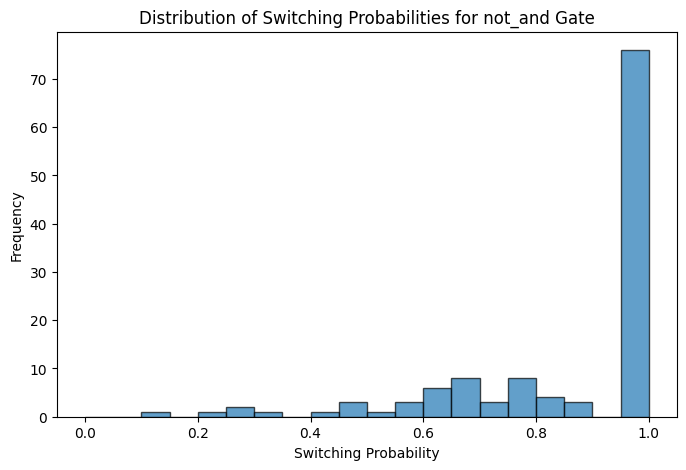

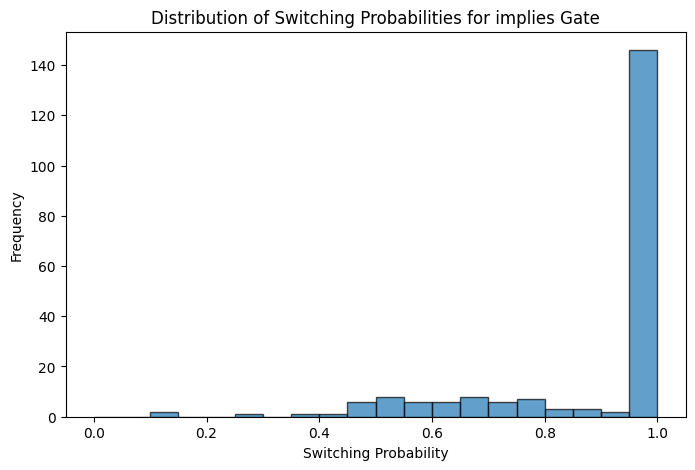

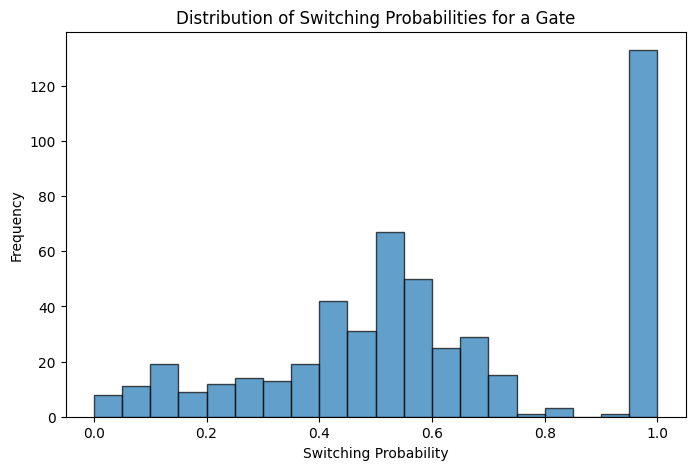

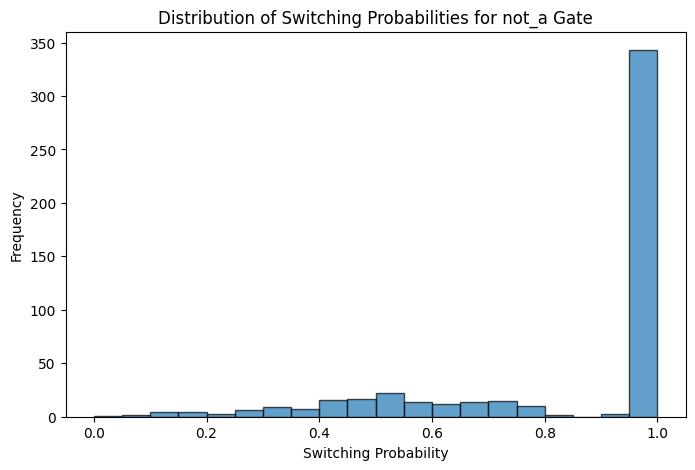

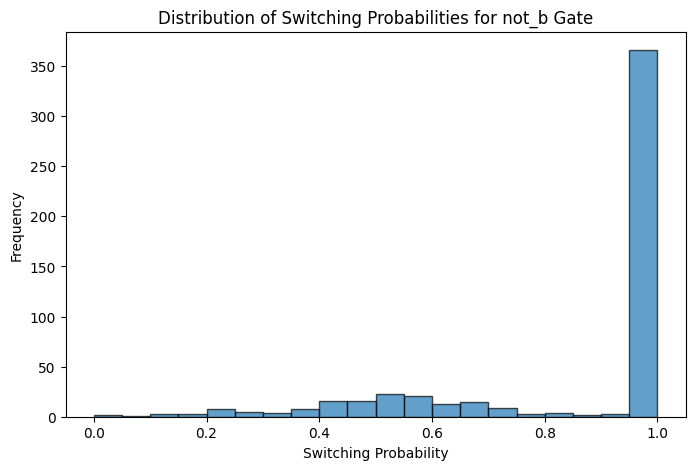

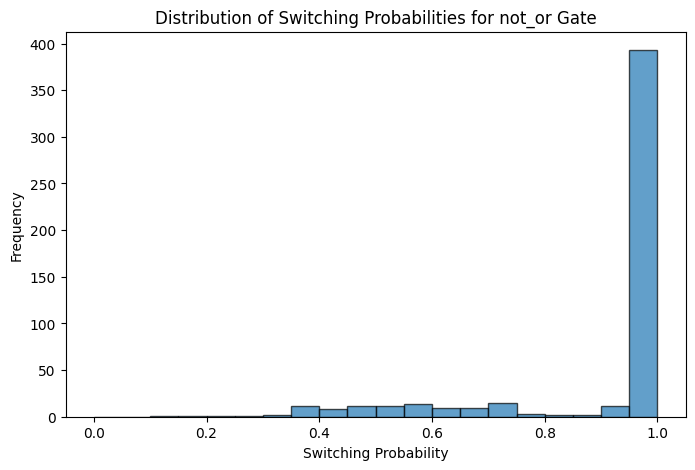

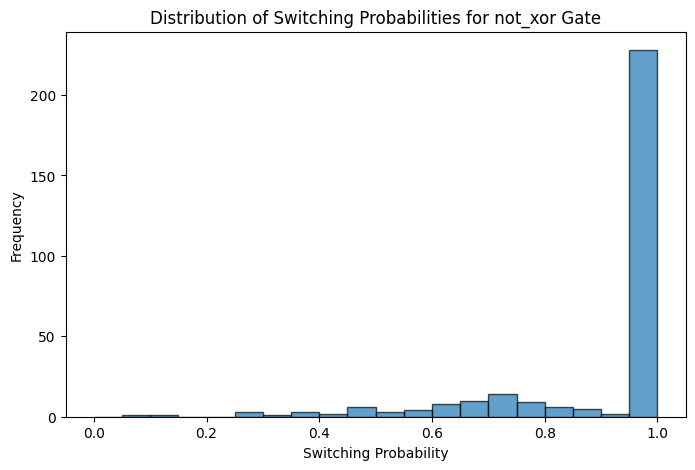

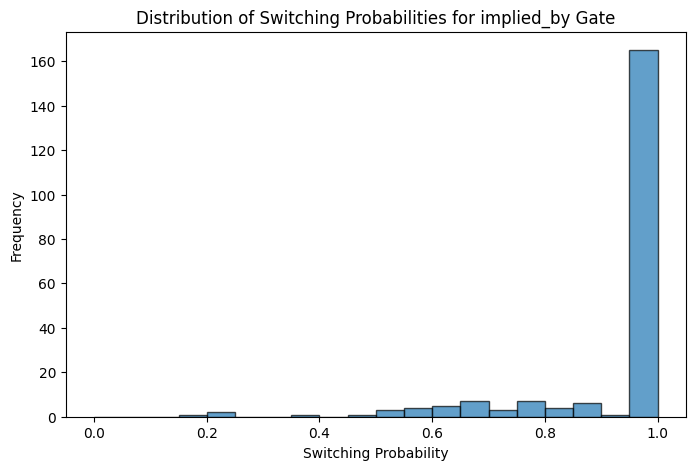

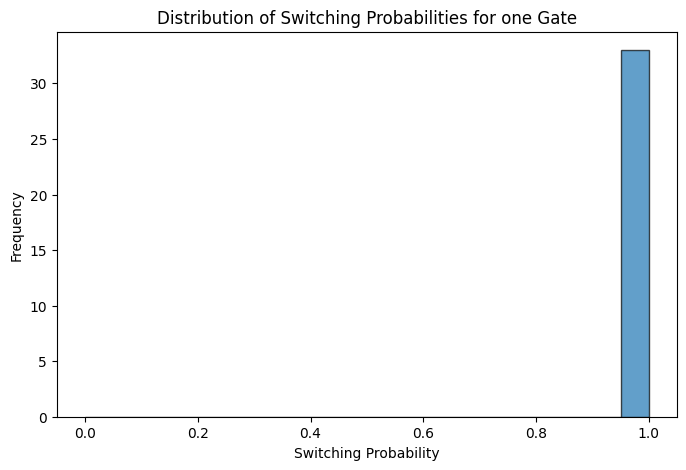

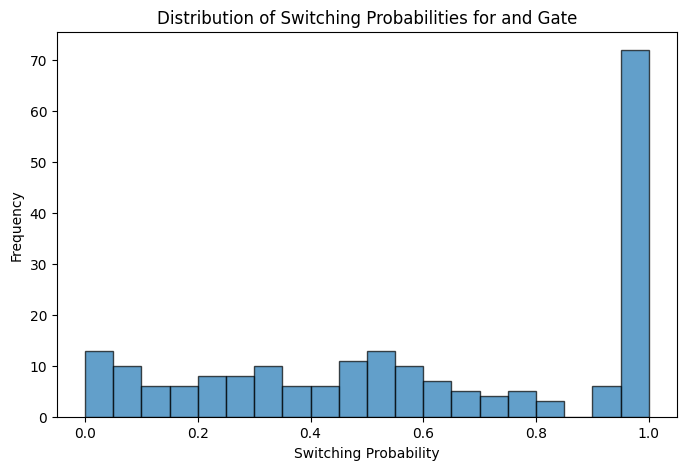

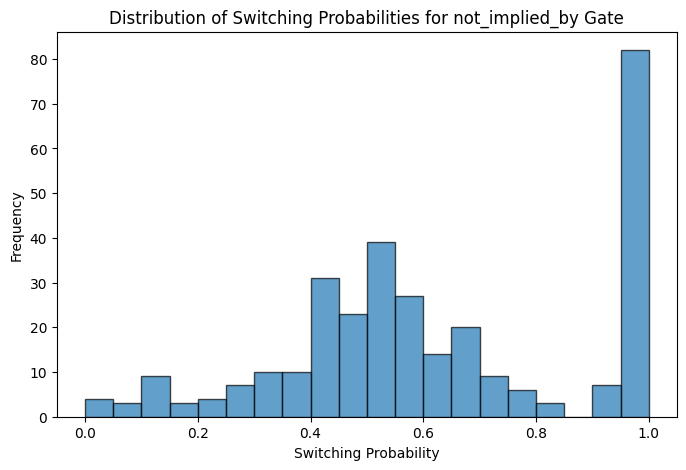

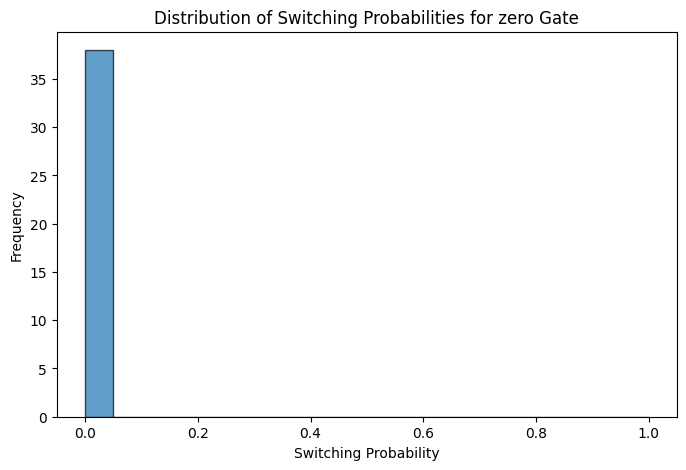

In [32]:
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_switching_probabilities_by_gate(gate_prob_dict_per_layer):
    """
    Plots the distribution of switching probabilities for each learned gate across layers using histograms.
    
    Args:
        gate_prob_dict_per_layer: A list of dictionaries per layer, each containing the learned gate and its switching probability for neurons in that layer.
    """
    # Dictionary to hold switching probabilities grouped by gate type
    gate_switching_probs = defaultdict(list)

    # Collect switching probabilities for each gate type across layers
    for layer_dict in gate_prob_dict_per_layer:
        for gate_key, gate_data in layer_dict.items():
            gate_type = gate_data['Learned Gate']  # The gate type (e.g., AND, OR, etc.)
            switching_prob = gate_data['Switching Probability']  # The switching probability for this neuron

            # Append the switching probability to the corresponding gate type
            gate_switching_probs[gate_type].append(switching_prob)

    # Plot the distribution of switching probabilities for each gate type
    for gate_type, probs in gate_switching_probs.items():
        plt.figure(figsize=(8, 5))
        plt.hist(probs, bins=20, range=(0, 1), edgecolor='black', alpha=0.7)
        plt.title(f"Distribution of Switching Probabilities for {gate_type} Gate")
        plt.xlabel("Switching Probability")
        plt.ylabel("Frequency")
        plt.show()

# Example usage with the output of your get_gate_switching_probs function
visualize_switching_probabilities_by_gate(gate_switching_probs)

##### Function Element Importance (Identify High-Activity Neurons)

In [26]:
def get_high_activity_neurons(gate_switching_probs, threshold=0.5):
    """
    Finds neurons with switching probability greater than a threshold, and their associated logic gates.
    
    Args:
        gate_switching_probs: Output from get_gate_switching_probs.
        threshold: Switching probability threshold to consider a neuron as high-activity.

    Returns:
        high_activity_neurons: A dictionary with layer, neuron index, learned gate, inputs, and switching probability.
    """
    high_activity_neurons = []

    for layer_idx, gates in enumerate(gate_switching_probs):
        for neuron_idx, gate_info in gates.items():
            if gate_info["Switching Probability"] >= threshold:
                high_activity_neurons.append({
                    "Layer": layer_idx + 1,
                    "Neuron": neuron_idx,
                    "Gate": gate_info["Learned Gate"],
                    "Inputs": gate_info["Inputs"],
                    "Switching Probability": gate_info["Switching Probability"]
                })
    
    return high_activity_neurons

high_activity_neurons = get_high_activity_neurons(gate_switching_probs, threshold=.99)
print(high_activity_neurons)

[{'Layer': 1, 'Neuron': 'Gate 5', 'Gate': 'not_and', 'Inputs': (49, 145), 'Switching Probability': 0.9916130514705882}, {'Layer': 1, 'Neuron': 'Gate 9', 'Gate': 'not_b', 'Inputs': (207, 341), 'Switching Probability': 0.9958639705882353}, {'Layer': 1, 'Neuron': 'Gate 25', 'Gate': 'one', 'Inputs': (84, 33), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 26', 'Gate': 'not_a', 'Inputs': (4, 111), 'Switching Probability': 0.9939108455882353}, {'Layer': 1, 'Neuron': 'Gate 33', 'Gate': 'not_xor', 'Inputs': (301, 40), 'Switching Probability': 0.9937959558823529}, {'Layer': 1, 'Neuron': 'Gate 43', 'Gate': 'not_a', 'Inputs': (223, 383), 'Switching Probability': 0.9909237132352942}, {'Layer': 1, 'Neuron': 'Gate 45', 'Gate': 'one', 'Inputs': (240, 13), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 47', 'Gate': 'implies', 'Inputs': (380, 121), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 53', 'Gate': 'not_or', 'Inputs': (392, 398), 'Switching Probability': 

##### Visualize Gate Distribution

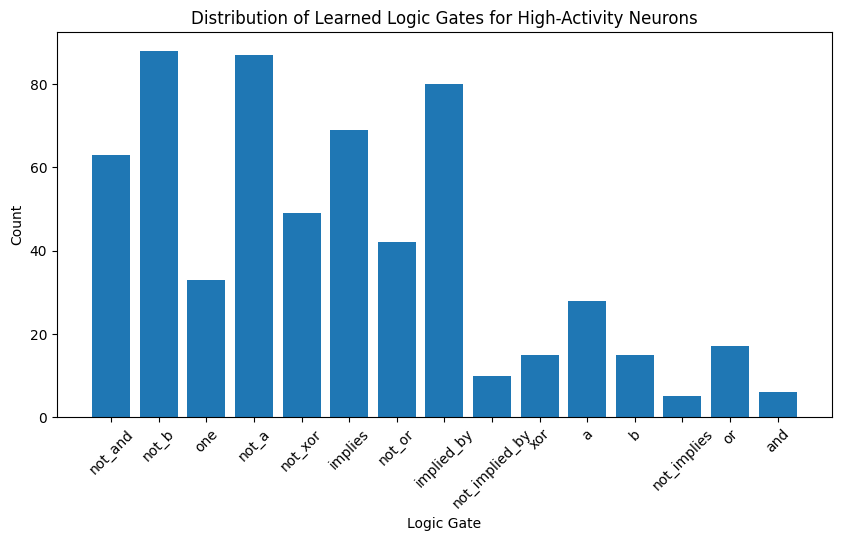

In [27]:
from collections import Counter

def visualize_gate_distribution(high_activity_neurons):
    """
    Plots a bar chart showing the distribution of learned logic gates for high-activity neurons.
    
    Args:
        high_activity_neurons: Output from get_high_activity_neurons.
    """
    # Count gate occurrences
    gate_counter = Counter([neuron["Gate"] for neuron in high_activity_neurons])
    
    # Plot bar chart
    plt.figure(figsize=(10, 5))
    plt.bar(gate_counter.keys(), gate_counter.values())
    plt.title("Distribution of Learned Logic Gates for High-Activity Neurons")
    plt.xlabel("Logic Gate")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Example usage:
visualize_gate_distribution(high_activity_neurons)

##### Trace Inputs Responsible for High-Activity Neurons

In [37]:
def trace_inputs_to_neurons(high_activity_neurons, model):
    """
    Trace the inputs responsible for activating high-activity neurons.
    
    Args:
        high_activity_neurons: Output from get_high_activity_neurons.
        model: The DiffLogic model with trained weights.
    
    Returns:
        input_traces: A list of dictionaries showing the input neurons connected to high-activity neurons.
    """
    input_traces = []
    
    for neuron_info in high_activity_neurons:
        layer_idx = neuron_info["Layer"] - 1  # Adjust layer index for 0-based indexing
        neuron_idx = neuron_info["Neuron"]
        
        # Extract the inputs to this neuron
        gate_inputs = neuron_info["Inputs"]
        
        # Store the trace info
        input_traces.append({
            "Layer": neuron_info["Layer"],
            "Neuron": neuron_idx,
            "Gate": neuron_info["Gate"],
            "Inputs": gate_inputs,
            "Switching Probability": neuron_info["Switching Probability"]
        })
    
    return input_traces

# Example usage:
input_traces = trace_inputs_to_neurons(high_activity_neurons, model)
print(input_traces)

[{'Layer': 1, 'Neuron': 'Gate 5', 'Gate': 'not_and', 'Inputs': (49, 145), 'Switching Probability': 0.9916866987179487}, {'Layer': 1, 'Neuron': 'Gate 9', 'Gate': 'not_b', 'Inputs': (207, 341), 'Switching Probability': 0.9959935897435898}, {'Layer': 1, 'Neuron': 'Gate 25', 'Gate': 'one', 'Inputs': (84, 33), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 26', 'Gate': 'not_a', 'Inputs': (4, 111), 'Switching Probability': 0.9939903846153846}, {'Layer': 1, 'Neuron': 'Gate 33', 'Gate': 'not_xor', 'Inputs': (301, 40), 'Switching Probability': 0.9943910256410257}, {'Layer': 1, 'Neuron': 'Gate 43', 'Gate': 'not_a', 'Inputs': (223, 383), 'Switching Probability': 0.9912860576923077}, {'Layer': 1, 'Neuron': 'Gate 45', 'Gate': 'one', 'Inputs': (240, 13), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 47', 'Gate': 'implies', 'Inputs': (380, 121), 'Switching Probability': 1.0}, {'Layer': 1, 'Neuron': 'Gate 53', 'Gate': 'not_or', 'Inputs': (392, 398), 'Switching Probability': 

##### Correlation Between Explanations and Model Behavior

In [48]:
model

Model(
  (diff_logic_model): DiffLogic(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (logic_layers): Sequential(
      (0): LogicLayer(400, 2500, eval)
      (1): LogicLayer(2500, 2500, eval)
    )
    (group): GroupSum(k=10, tau=10)
  )
  (criterion): CrossEntropyLoss()
)

In [45]:
device = 'cuda'
import torch.nn.functional as F

# Function to calculate model outputs
def calculate_model_outputs(model, data_loader):
    model_outputs = []
    model.diff_logic_model.eval()  # Set model to evaluation mode
    
    with torch.no_grad():  # Disable gradient calculation for inference
        for inputs, labels in data_loader:
            inputs = inputs.to(device)  # Move inputs to the correct device (GPU/CPU)
            
            # Get the model outputs (logits)
            outputs = model.diff_logic_model(inputs)
            
            # If the output is logits, apply softmax to get probabilities
            probabilities = F.softmax(outputs, dim=1)
            
            # Store the model outputs (for each class, or you can extract max probability class)
            model_outputs.append(probabilities.cpu().numpy())  # Move to CPU and convert to numpy
    
    # Concatenate all outputs into a single array
    model_outputs = np.concatenate(model_outputs, axis=0)
    
    return model_outputs

model_outputs = calculate_model_outputs(model, test_loader)

In [47]:
model_outputs.shape

(9984, 10)

In [55]:
len(switching_probs[0])

2500

ValueError: x and y must be the same size

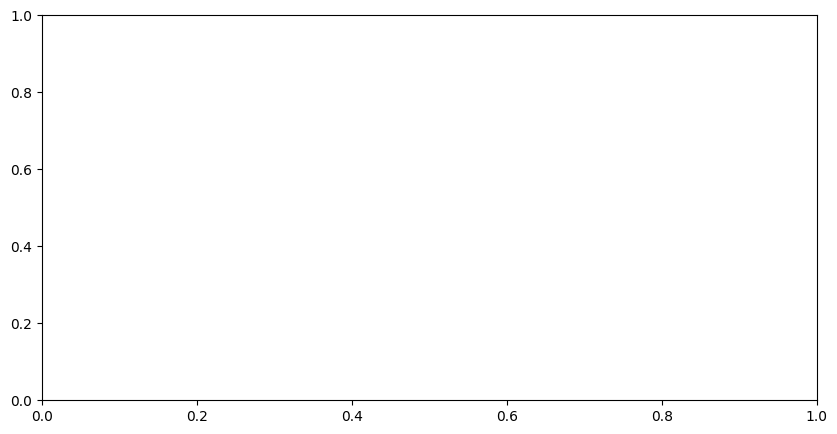

In [49]:
def plot_switching_prob_vs_performance(switching_probs, model_outputs):
    """
    Plots the correlation between neuron switching probabilities and how well the neuron predicts a class.
    
    Args:
        switching_probs: List of arrays with neuron switching probabilities per layer.
        model_outputs: List of model outputs corresponding to each input class.
    """
    for layer_idx, layer_probs in enumerate(switching_probs):
        plt.figure(figsize=(10, 5))
        plt.scatter(model_outputs, layer_probs)
        plt.title(f"Correlation between Model Output and Switching Probabilities for Layer {layer_idx + 1}")
        plt.xlabel("Model Output")
        plt.ylabel("Switching Probability")
        plt.show()

# Example usage:
# Assume `model_outputs` are already calculated or extracted
plot_switching_prob_vs_performance(switching_probs, model_outputs)

##### Compare With Standard Explanation Methods

In [ ]:
def vanilla_gradients(model, inputs):
    """
    Computes vanilla gradients of the input with respect to the model outputs.
    
    Args:
        model: The trained DiffLogic model.
        inputs: Input images (e.g., from the MNIST dataset).
    
    Returns:
        gradients: The computed vanilla gradients.
    """
    model.zero_grad()  # Zero out previous gradients
    inputs.requires_grad = True  # Enable gradient computation for inputs
    
    outputs = model(inputs)
    outputs.backward(torch.ones_like(outputs))  # Backpropagate all outputs
    
    gradients = inputs.grad  # Get the gradients of the inputs
    
    return gradients.cpu().detach().numpy()

# Example usage:
# Compute vanilla gradients for a batch of input images
for batch_inputs, _ in test_loader:
    gradients = vanilla_gradients(model, batch_inputs.to('cuda'))
    print(gradients)
    break

### Network Visualization Graph Creation

In [84]:
import networkx as nx
import plotly.graph_objects as go

In [91]:
# code below currently used for testing, move into a function later

G = nx.DiGraph()
num_inputs = 400
positions = {}
layer_offset = 0  # For controlling vertical positioning
input_layer_name = 'L0'

for i in range(num_inputs):
    node_name = f"{input_layer_name}_N{i+1}"
    G.add_node(node_name, layer=0)
    positions[node_name] = (0, -i + layer_offset)  # (x, y) coordinates for positioning

#G.nodes

num_layers = len(gate_switching_probs)

layers_data = gate_switching_probs

for layer_idx, layer in enumerate(layers_data):
    num_neurons = len(layer)
    #print(num_neurons)
    for i in range(num_neurons):
        node_name = f"L{layer_idx+1}_N{i+1}"  # Use "N" for neuron index
        G.add_node(node_name, layer=layer_idx + 1)
        positions[node_name] = (layer_idx + 1, -i + layer_offset)  # (x, y) coordinates

    # Increase the layer offset to visually separate layers
    layer_offset += num_neurons
    
#G.nodes

#print(layers_data[0])

for gate_idx, gate_info in layers_data[0].items():  # Layer 1
    inputs = gate_info['Inputs']
    current_node = f"L1_N{int(gate_idx.split()[1])}"  # Use neuron index, not 'Gate' prefix
    #print(current_node)
    
    input_node_1 = f"L0_N{inputs[0]+1}"  # Input layer node (L0)
    input_node_2 = f"L0_N{inputs[1]+1}"

    #print(input_node_1, input_node_2, current_node)
    
    G.add_edge(input_node_1, current_node)  # Edge from input layer to logic layer 1
    G.add_edge(input_node_2, current_node)
    

# Add edges between logic layers (Layer 1 -> Layer 2)
for layer_idx, layer in enumerate(layers_data[1:]):  # Don't add edges from the last layer
    next_layer_idx = layer_idx + 1  # Ensure we're connecting the current layer to the next layer
    for gate_idx, gate_info in layer.items():
        inputs = gate_info['Inputs']  # This should be a tuple (input_node1, input_node2)
        
        current_node = f"L{layer_idx+1}_N{int(gate_idx.split()[1])}"  # Use neuron index for current node
        
        # Connect to the next logic layer (next_layer_idx + 1)
        next_layer_node = f"L{next_layer_idx+1}_N{int(gate_idx.split()[1])}"

        input_node_1 = f"L{layer_idx+1}_N{inputs[0]+1}"  # From current layer
        input_node_2 = f"L{layer_idx+1}_N{inputs[1]+1}"

        # Add edges from the current node to the next layer node
        G.add_edge(input_node_1, next_layer_node)
        G.add_edge(input_node_2, next_layer_node)
        #print(input_node_1, input_node_2, next_layer_node)

num_outputs = 10
output_layer_idx = num_layers + 1  # Layer index for the output layer
for i in range(num_outputs):
    output_node = f"L{output_layer_idx}_N{i+1}"  
    G.add_node(output_node, layer=output_layer_idx)
    positions[output_node] = (output_layer_idx, -i + layer_offset)

    # Connect last logic layer to output
    for gate_idx, gate_info in layers_data[-1].items():  # Last logic layer
        current_node = f"L{num_layers}_N{int(gate_idx.split()[1])}"  # Current node in last layer
        #print(current_node, output_node)
        G.add_edge(current_node, output_node)
        
#positions, G

model_name_graph = model_name + '.html'

plot_neural_network(G, positions, model_name_graph)

In [57]:
def create_neural_network_graph(layers_data):
    """
    Creates a directed graph for the neural network layers and their connections.

    Args:
        layers_data (list): A list of dictionaries containing gate information for each layer. 
                            Each dictionary contains learned gate and its inputs (connections).

    Returns:
        G (networkx.DiGraph): A directed graph representing the neural network.
    """
    G = nx.DiGraph()  # Create a directed graph

    # Add input layer (Layer 0) with 400 nodes
    num_inputs = 400
    positions = {}
    layer_offset = 0  # For controlling vertical positioning
    input_layer_name = 'L0'
    
    # Create input layer nodes (400 nodes)
    for i in range(num_inputs):
        node_name = f"{input_layer_name}_N{i+1}"
        G.add_node(node_name, layer=0)
        positions[node_name] = (0, -i + layer_offset)  # (x, y) coordinates for positioning

    # Add nodes for each subsequent logic layer (e.g., Layer 1 and Layer 2)
    num_layers = len(layers_data)
    
    for layer_idx, layer in enumerate(layers_data):
        num_neurons = len(layer)
        for i in range(num_neurons):
            node_name = f"L{layer_idx+1}_N{i+1}"  # Use "N" for neuron index
            G.add_node(node_name, layer=layer_idx + 1)
            positions[node_name] = (layer_idx + 1, -i + layer_offset)  # (x, y) coordinates

        # Increase the layer offset to visually separate layers
        layer_offset += num_neurons

    # Add connections from input layer (Layer 0) to first logic layer (Layer 1)
    for gate_idx, gate_info in layers_data[0].items():  # Layer 1
        inputs = gate_info['Inputs']
        current_node = f"L1_N{int(gate_idx.split()[1])}"  # Use neuron index, not 'Gate' prefix
        
        input_node_1 = f"L0_N{inputs[0]+1}"  # Input layer node (L0)
        input_node_2 = f"L0_N{inputs[1]+1}"
        
        G.add_edge(input_node_1, current_node)  # Edge from input layer to logic layer 1
        G.add_edge(input_node_2, current_node)

    # Add edges between logic layers (Layer 1 -> Layer 2)
    for layer_idx, layer in enumerate(layers_data[1:]):  # Don't add edges from the last layer
        next_layer_idx = layer_idx + 1  # Ensure we're connecting the current layer to the next layer
        for gate_idx, gate_info in layer.items():
            inputs = gate_info['Inputs']  # This should be a tuple (input_node1, input_node2)
            current_node = f"L{layer_idx+1}_N{int(gate_idx.split()[1])}"  # Use neuron index for current node

            # Connect to the next logic layer (next_layer_idx + 1)
            next_layer_node = f"L{next_layer_idx+1}_N{int(gate_idx.split()[1])}"

            curr_layer_input_node_1 = f"L{layer_idx+1}_N{inputs[0]+1}"  # From current layer
            curr_layer_input_node_2 = f"L{layer_idx+1}_N{inputs[1]+1}"

            # Add edges from the current node to the next layer node
            G.add_edge(curr_layer_input_node_1, next_layer_node)
            G.add_edge(curr_layer_input_node_2, next_layer_node)

    # Add output layer with 10 nodes
    num_outputs = 10
    output_layer_idx = num_layers + 1  # Layer index for the output layer
    for i in range(num_outputs):
        output_node = f"L{output_layer_idx}_N{i+1}"  
        G.add_node(output_node, layer=output_layer_idx)
        positions[output_node] = (output_layer_idx, -i + layer_offset)

        # Connect last logic layer (Layer 2) to the output layer
        for gate_idx, gate_info in layers_data[-1].items():  # Last logic layer (Layer 2)
            current_node = f"L{num_layers}_N{int(gate_idx.split()[1])}"  # Current node in Layer 2
            G.add_edge(current_node, output_node)

    return G, positions

### Plotting the Neural Network

In [65]:
import plotly.io as pio
import webbrowser
import os

def plot_neural_network(G, positions, filename='neural_network_graph.html'):
    """
    Plots the neural network graph using Plotly and saves it as an HTML file.

    Args:
        G (networkx.DiGraph): The directed graph representing the neural network.
        positions (dict): A dictionary containing the positions for each node in the graph.
        filename (str): The name of the HTML file to save the plot.
    """
    edge_x = []
    edge_y = []

    for edge in G.edges():
        x0, y0 = positions[edge[0]]
        x1, y1 = positions[edge[1]]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines')

    node_x = []
    node_y = []
    node_text = []

    for node in G.nodes():
        x, y = positions[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=10,
            colorbar=dict(
                thickness=15,
                title='Neuron Activation',
                xanchor='left',
                titleside='right'
            ),
            line_width=2),
        text=node_text
    )

    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title='<br>Neural Network Graph',
                        titlefont_size=16,
                        showlegend=False,
                        hovermode='closest',
                        margin=dict(b=0, l=0, r=0, t=0),
                        annotations=[dict(
                            text="Neural Network Structure",
                            showarrow=False,
                            xref="paper", yref="paper",
                            x=0.005, y=-0.002)],
                        xaxis=dict(showgrid=False, zeroline=False),
                        yaxis=dict(showgrid=False, zeroline=False))
                    )

    # Save figure as an HTML file
    pio.write_html(fig, file=filename)

    # Open the HTML file in a new browser tab
    full_path = os.path.abspath(filename)
    webbrowser.open(f'file://{full_path}')